# Model development

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parents[1]
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [2]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from lazypredict.Supervised import LazyClassifier

from src.data.load_data import load_raw_data, split_features_target
from src.utils.config import RANDOM_STATE, TEST_SIZE

## Train/test split

In [3]:
df = load_raw_data()
X, y = split_features_target(df)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

X_train.shape, X_test.shape

((100, 6), (26, 6))

Stratified so the 55/45 split found in EDA is preserved in both the train and test sets.

Note from EDA: 16 rows in the full dataset are exact duplicates. This split does not account for that.

## LazyPredict screening

In [4]:
clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
models, predictions = clf.fit(X_train, X_test, y_train, y_test)
models

,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Precision,Recall,Time Taken
Model,,,,,,,
AdaBoostClassifier,0.730769,0.714286,0.767857,0.715740,0.764025,0.730769,0.073685
SGDClassifier,0.692308,0.690476,0.767857,0.692308,0.692308,0.692308,0.014148
NearestCentroid,0.692308,0.684524,0.779762,0.688578,0.693269,0.692308,0.015160
BernoulliNB,0.692308,0.678571,0.788690,0.680769,0.705128,0.692308,0.037889
DecisionTreeClassifier,0.653846,0.660714,0.660714,0.652308,0.668531,0.653846,0.013562
RandomForestClassifier,0.653846,0.660714,0.678571,0.652308,0.668531,0.653846,0.107336
CalibratedClassifierCV,0.653846,0.630952,0.696429,0.617195,0.702564,0.653846,0.032777
ExtraTreesClassifier,0.615385,0.613095,0.616071,0.615385,0.615385,0.615385,0.084653
BaggingClassifier,0.615385,0.613095,0.622024,0.615385,0.615385,0.615385,0.028184


AdaBoost and RandomForest were the two strongest results in this table and were moved forward into tuning. GradientBoosting was added since LazyPredict doesn't test it by default.

## Hyperparameter tuning

Using train_test_split for a single validation split.

In [5]:
from src.models.train import MODELS, tune_model

In [6]:
import pandas as pd

rows = []
for name in MODELS:
    search = tune_model(name, X_train, y_train)
    rows.append({
        "model": name,
        "val_score": search.best_score_,
        "best_params": search.best_params_,
    })

results_df = pd.DataFrame(rows)
results_df

,model,val_score,best_params
0,AdaBoost,0.65,"{'learning_rate': 0.5, 'n_estimators': 40}"
1,GradientBoosting,0.70,"{'learning_rate': 0.005, 'n_estimators': 100}"
2,RandomForest,0.75,"{'max_depth': None, 'n_estimators': 50}"


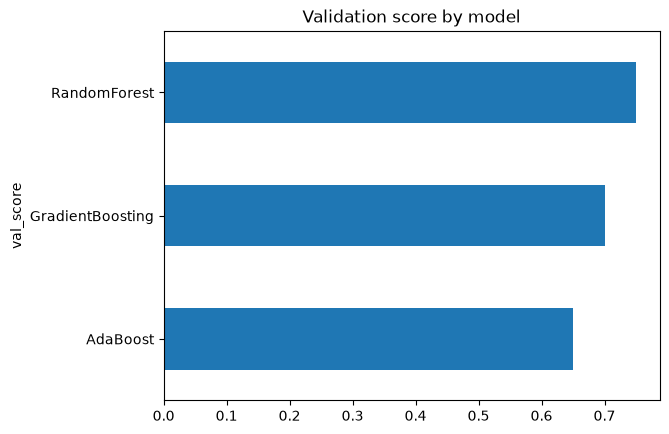

In [7]:
results_df.plot(x="model", y="val_score", kind="barh", legend=False)
plt.title("Validation score by model")
plt.ylabel("val_score")
plt.show()

RandomForest scored the highest here, but this is a single ~20-row validation split, so the estimate is noisy and could be luck rather than a real advantage.

## Final evaluation

In [8]:
from src.models.evaluate import print_report, plot_confusion_matrix, plot_feature_importance
from src.utils.config import FEATURE_COLS

final_models = {}
for name in MODELS:
    search = tune_model(name, X_train, y_train)
    final_models[name] = search.best_estimator_

=== AdaBoost ===
              precision    recall  f1-score   support

     unhappy       0.73      0.67      0.70        12
       happy       0.73      0.79      0.76        14

    accuracy                           0.73        26
   macro avg       0.73      0.73      0.73        26
weighted avg       0.73      0.73      0.73        26

beat 73% target: True


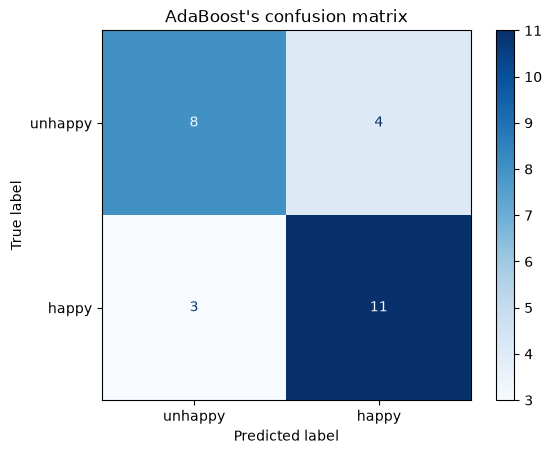

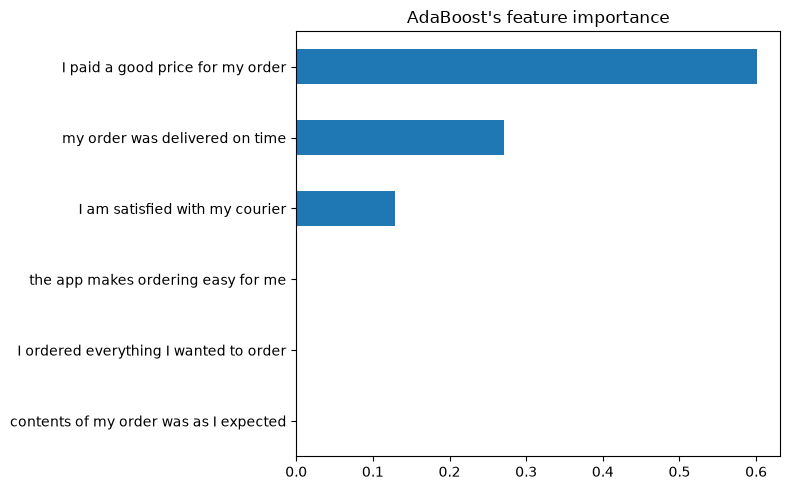

=== GradientBoosting ===
              precision    recall  f1-score   support

     unhappy       1.00      0.50      0.67        12
       happy       0.70      1.00      0.82        14

    accuracy                           0.77        26
   macro avg       0.85      0.75      0.75        26
weighted avg       0.84      0.77      0.75        26

beat 73% target: True


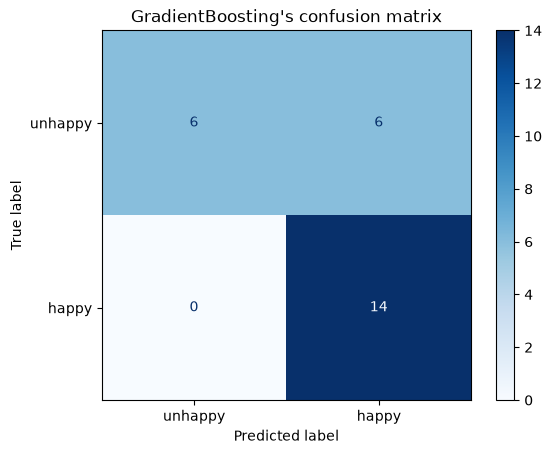

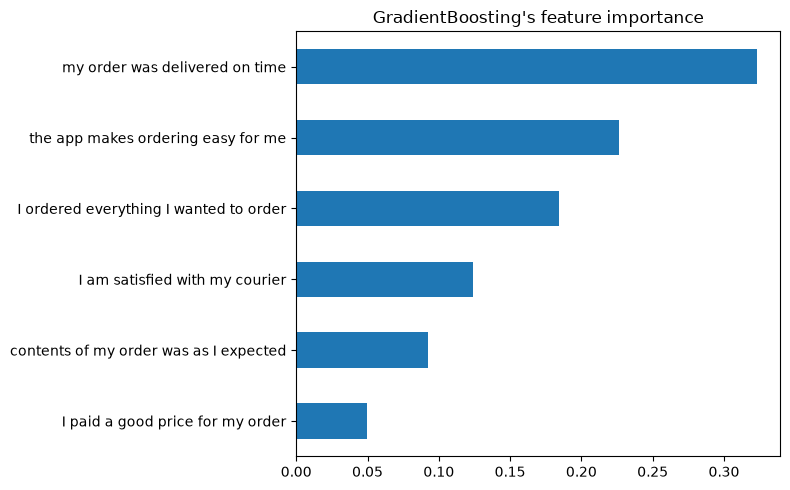

=== RandomForest ===
              precision    recall  f1-score   support

     unhappy       0.54      0.58      0.56        12
       happy       0.62      0.57      0.59        14

    accuracy                           0.58        26
   macro avg       0.58      0.58      0.58        26
weighted avg       0.58      0.58      0.58        26

beat 73% target: False


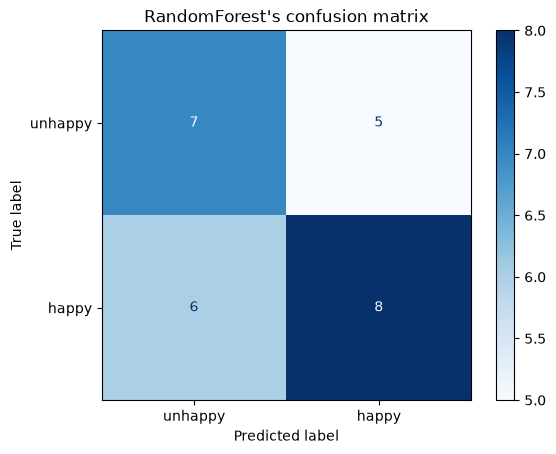

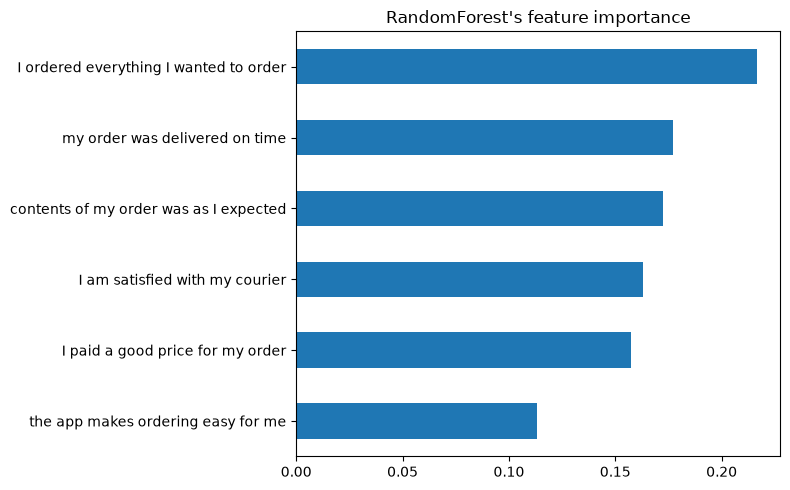

In [9]:
for name, model in final_models.items():
    print_report(model, X_test, y_test, model_name=name)
    plot_confusion_matrix(model, X_test, y_test, model_name=name)
    plot_feature_importance(model, FEATURE_COLS, model_name=name)

## Summary

- GradientBoosting has the highest test accuracy (77%), followed by AdaBoost (73%). Both clear the 73% target; RandomForest does not (58%).
- RandomForest scored highest on the internal validation split (0.75) but ended up the weakest on the real test set.
- GradientBoosting only catches half of the unhappy customers (50% recall), despite being perfectly precise when it does flag one (100% precision). AdaBoost catches two-thirds (67%), with a more even balance across both classes.
- Given the project's goal is flagging unhappy customers for follow-up, AdaBoost's more balanced recall may make it the more practically useful choice, even though GradientBoosting scores higher on raw accuracy.

## Save final model

In [ ]:
import joblib

from src.utils.config import MODEL_PATH, PROJECT_ROOT

MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(final_models["GradientBoosting"], MODEL_PATH)
print(f"Saved model to {MODEL_PATH.relative_to(PROJECT_ROOT)}")

Saved model to models\best_model.joblib
